# AI4I 2020 데이터 전처리 및 모델 성능 분석
**HybridPdM - DenoisingAutoencoder 기반 이상 탐지**

PDF 샘플(장현진) 구조를 참고하여 실제 프로젝트 데이터로 재구성

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc,
    f1_score, precision_score, recall_score, roc_auc_score
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ── 스타일 ───────────────────────────────────────────────────
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

GREEN = '#3a9a5c'
RED   = '#e05c5c'
BLUE  = '#4a7fc1'

DATA_PATH = Path('../dataset/ai4i2020.csv')
print('설정 완료')

설정 완료


---
## 01 데이터셋 로드 및 개요

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'총 샘플 수: {len(df):,}')
print(f'컬럼: {df.columns.tolist()}')
df.head()

총 샘플 수: 10,000
컬럼: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
# 피처 / 레이블 컬럼 분류
NUM_COLS = ['Air temperature [K]', 'Process temperature [K]',
            'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
FAULT_TYPES = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

total = len(df)
n_fail = df['Machine failure'].sum()
n_normal = total - n_fail

print(f'정상: {n_normal:,} ({n_normal/total*100:.1f}%)')
print(f'불량: {n_fail:,}  ({n_fail/total*100:.1f}%)')
print()
for ft in FAULT_TYPES:
    cnt = df[ft].sum()
    print(f'  {ft}: {cnt}개  ({cnt/n_fail*100:.1f}% of failures)')

정상: 9,661 (96.6%)
불량: 339  (3.4%)

  TWF: 46개  (13.6% of failures)
  HDF: 115개  (33.9% of failures)
  PWF: 95개  (28.0% of failures)
  OSF: 98개  (28.9% of failures)
  RNF: 19개  (5.6% of failures)


---
## 02 데이터 전처리 시각화

### 2-1. 클래스 불균형 (Pie Chart)

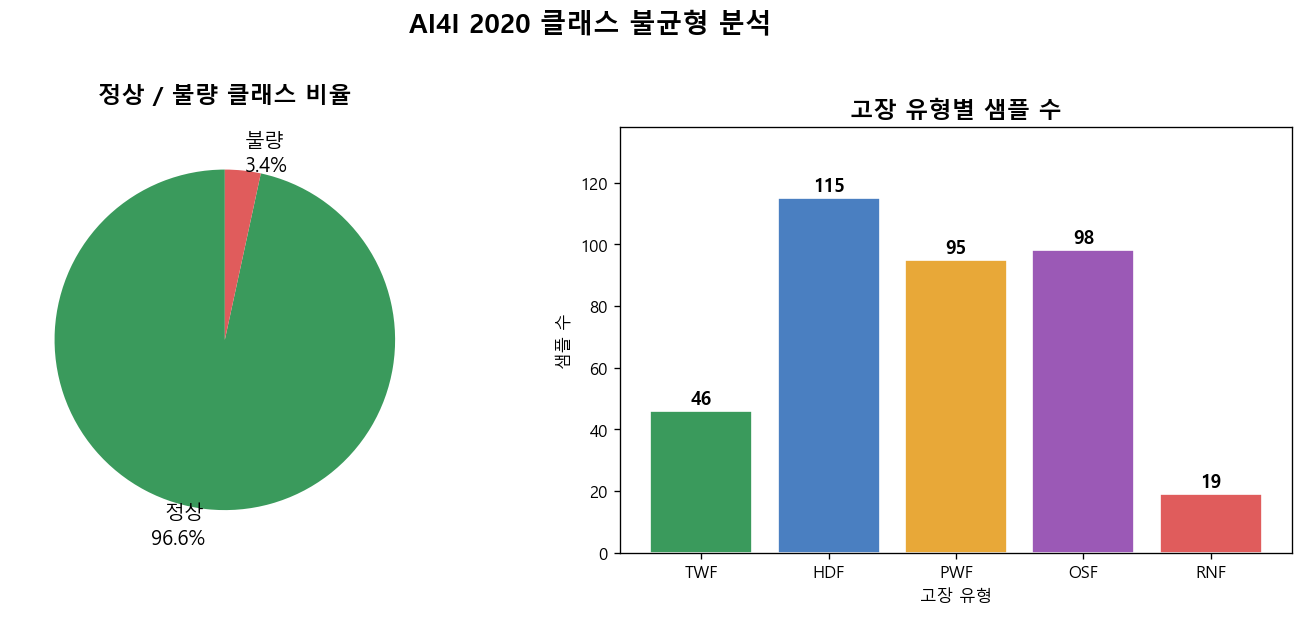

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── 정상/불량 비율 파이 ─────────────────────────────────────
ax = axes[0]
sizes  = [n_normal, n_fail]
labels = [f'정상\n{n_normal/total*100:.1f}%', f'불량\n{n_fail/total*100:.1f}%']
colors = [GREEN, RED]
wedges, texts = ax.pie(sizes, labels=labels, colors=colors,
                        startangle=90, textprops={'fontsize': 12})
ax.set_title('정상 / 불량 클래스 비율', fontsize=14, fontweight='bold', pad=15)

# ── 불량 유형별 개수 막대 ───────────────────────────────────
ax2 = axes[1]
fault_counts = df[FAULT_TYPES].sum()
bars = ax2.bar(fault_counts.index, fault_counts.values,
               color=[GREEN, BLUE, '#e8a838', '#9b59b6', '#e05c5c'], edgecolor='white')
for bar, v in zip(bars, fault_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(v), ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.set_title('고장 유형별 샘플 수', fontsize=14, fontweight='bold')
ax2.set_xlabel('고장 유형')
ax2.set_ylabel('샘플 수')
ax2.set_ylim(0, fault_counts.max() * 1.2)

plt.suptitle('AI4I 2020 클래스 불균형 분석', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 2-2. Feature 상관관계 히트맵

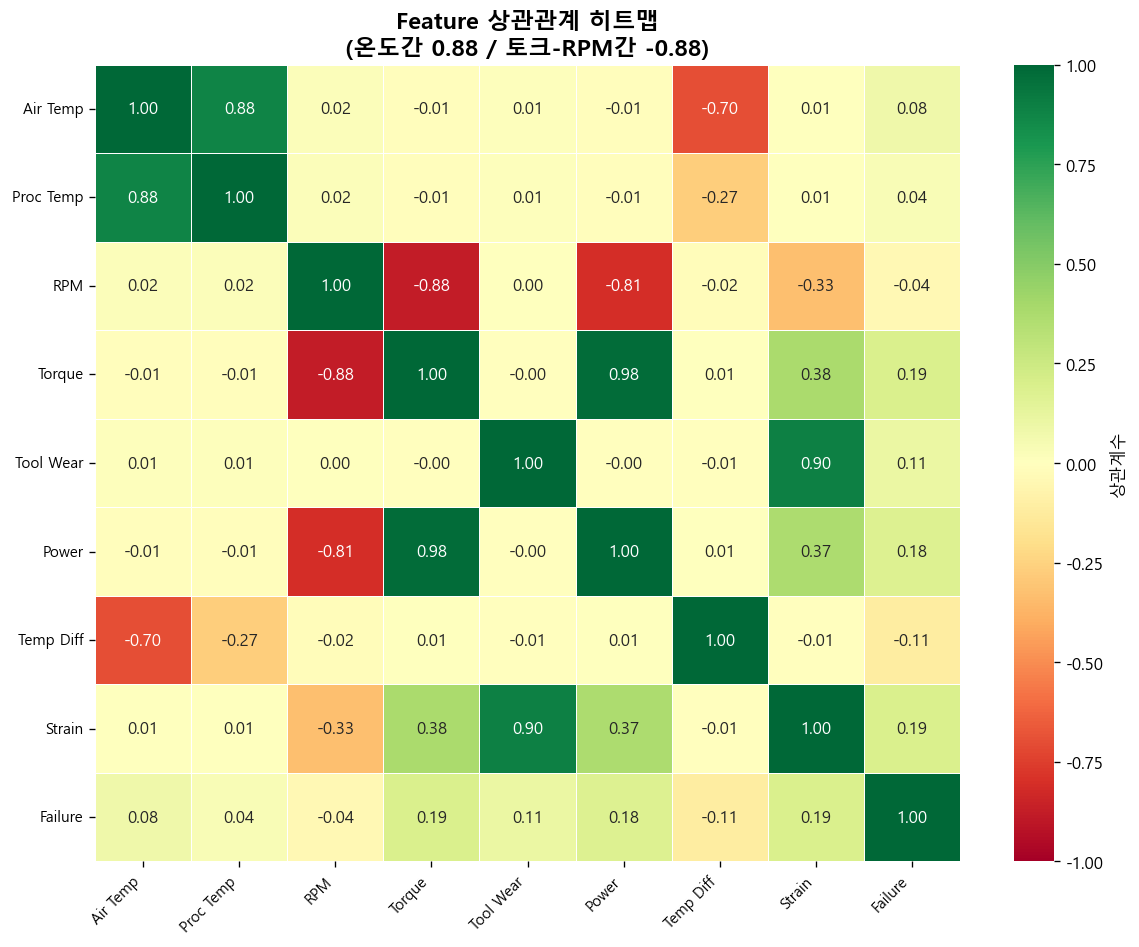

In [5]:
# 파생 피처 추가
df['power']     = df['Rotational speed [rpm]'] * df['Torque [Nm]']
df['temp_diff'] = df['Process temperature [K]'] - df['Air temperature [K]']
df['strain']    = df['Tool wear [min]'] * df['Torque [Nm]']

FEAT_COLS = NUM_COLS + ['power', 'temp_diff', 'strain', 'Machine failure']

corr = df[FEAT_COLS].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax,
            cbar_kws={'label': '상관계수'})

short_names = ['Air Temp', 'Proc Temp', 'RPM', 'Torque', 'Tool Wear',
               'Power', 'Temp Diff', 'Strain', 'Failure']
ax.set_xticklabels(short_names, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(short_names, rotation=0, fontsize=9)
ax.set_title('Feature 상관관계 히트맵\n(온도간 0.88 / 토크-RPM간 -0.88)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2-3. 센서별 분포 및 이상치 분석

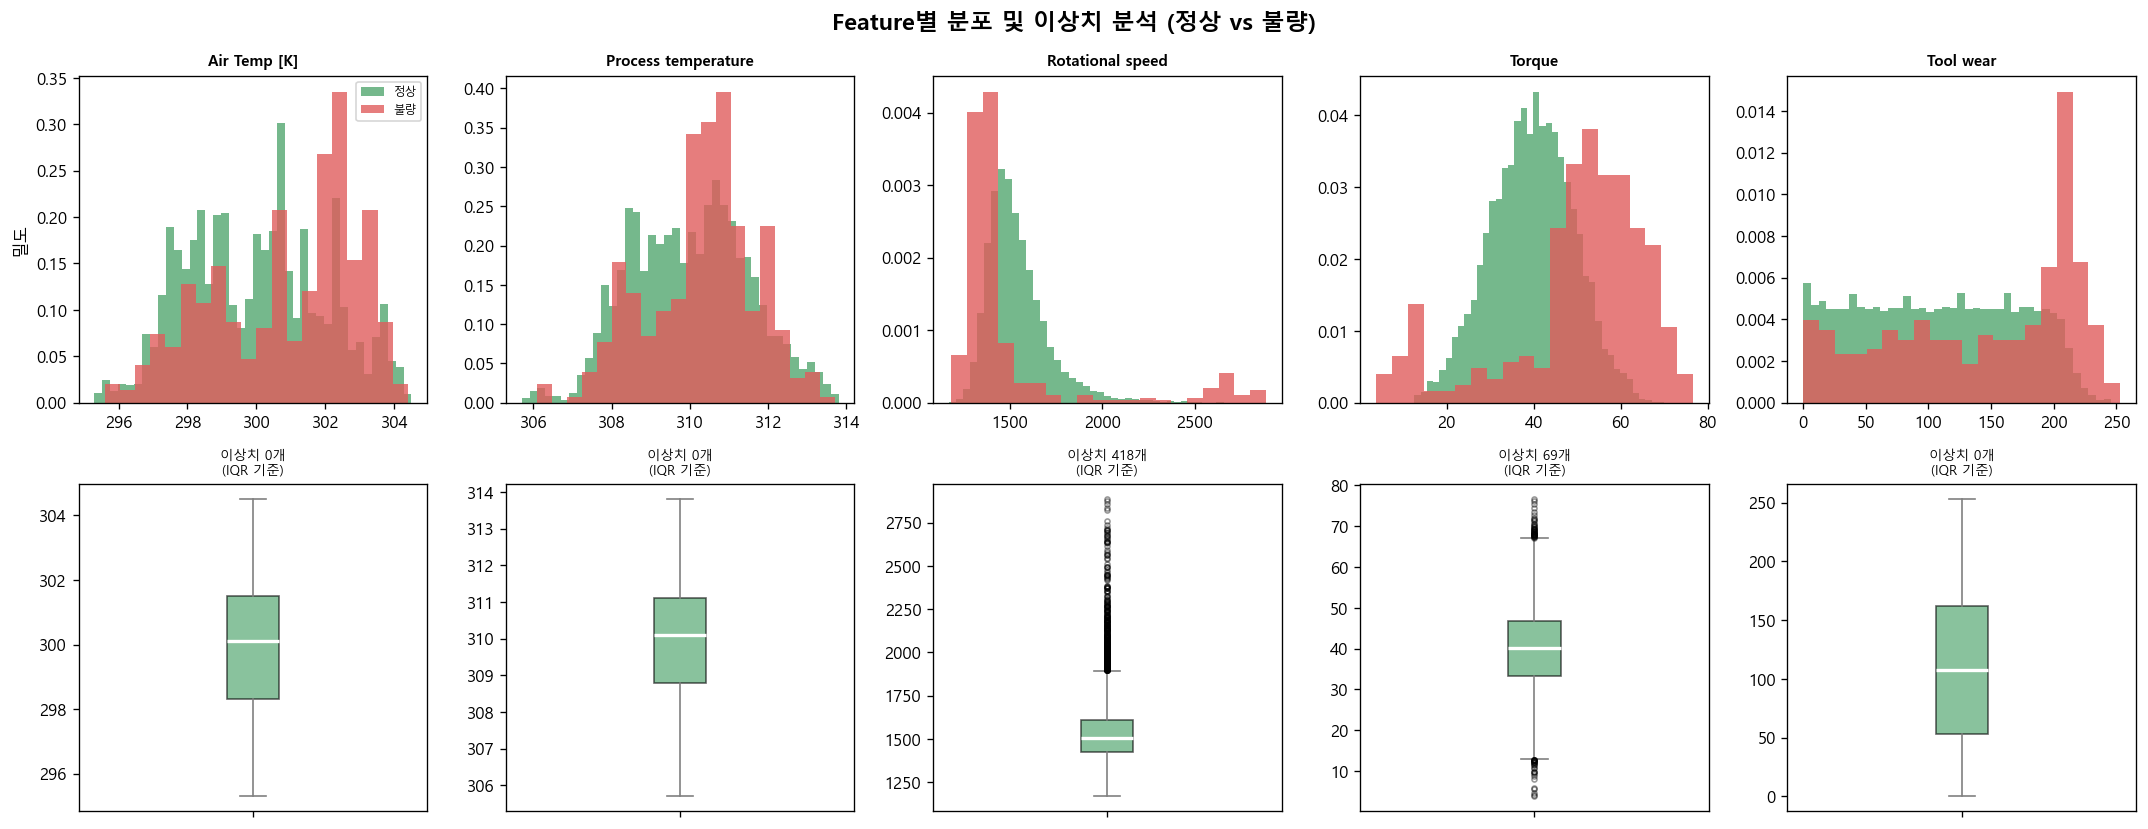

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))

for i, col in enumerate(NUM_COLS):
    ax_hist = axes[0][i]
    ax_box  = axes[1][i]
    short   = col.split('[')[0].strip()

    # 정상/불량 분리
    normal_vals = df.loc[df['Machine failure'] == 0, col].dropna()
    fail_vals   = df.loc[df['Machine failure'] == 1, col].dropna()

    # ── 히스토그램 (정규분포 분리) ─────────────────────────────
    ax_hist.hist(normal_vals, bins=40, color=GREEN, alpha=0.7, label='정상', density=True)
    ax_hist.hist(fail_vals,   bins=20, color=RED,   alpha=0.8, label='불량', density=True)
    ax_hist.set_title(short, fontsize=9, fontweight='bold')
    ax_hist.set_ylabel('밀도' if i == 0 else '')
    if i == 0:
        ax_hist.legend(fontsize=7)

    # ── 박스플롯 (IQR 이상치 표시) ─────────────────────────────
    combined = df[col].dropna()
    Q1, Q3 = combined.quantile(0.25), combined.quantile(0.75)
    IQR = Q3 - Q1
    outlier_mask = (combined < Q1 - 1.5*IQR) | (combined > Q3 + 1.5*IQR)
    n_outliers = outlier_mask.sum()

    bp = ax_box.boxplot(combined, patch_artist=True,
                        boxprops=dict(facecolor=GREEN, alpha=0.6),
                        medianprops=dict(color='white', linewidth=2),
                        whiskerprops=dict(color='gray'),
                        capprops=dict(color='gray'),
                        flierprops=dict(marker='o', color=RED, alpha=0.4, markersize=3))
    ax_box.set_xticklabels([])
    ax_box.set_title(f'이상치 {n_outliers}개\n(IQR 기준)', fontsize=8)

axes[0][0].set_title('Air Temp [K]', fontsize=9, fontweight='bold')
plt.suptitle('Feature별 분포 및 이상치 분석 (정상 vs 불량)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2-4. 학습/검증/테스트 분할 및 데이터 전처리 파이프라인

=== 데이터 분할 결과 ===
  Train (정상만, AE용):  6763개  (정상만)
  Train (전체):  7000개  (불량 237개)
  Validation:  1500개  (불량 51개)
  Test:  1500개  (불량 51개)


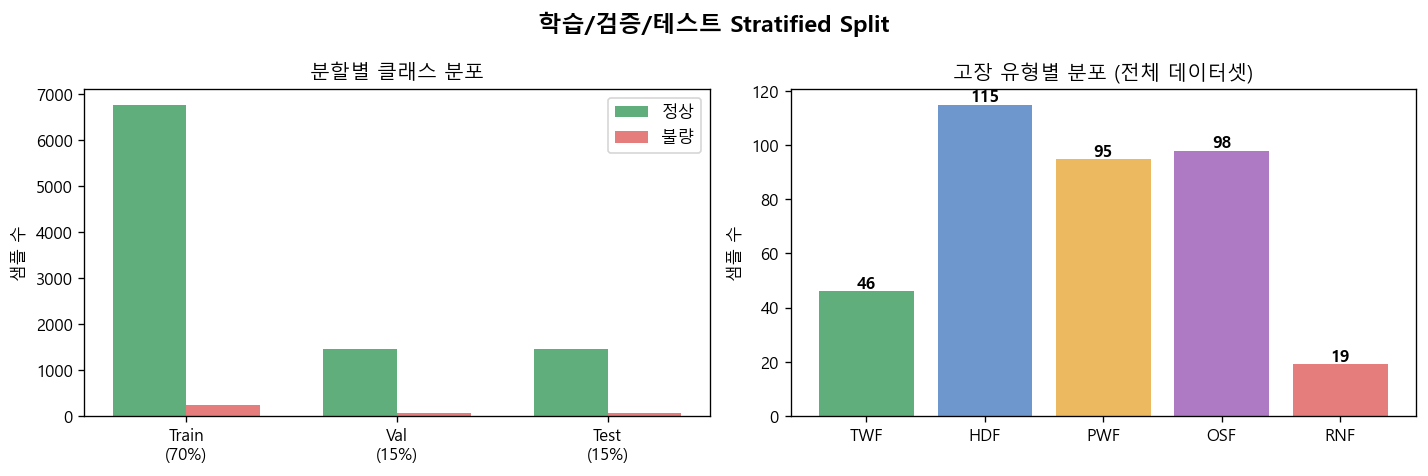

In [7]:
# ── 피처 엔지니어링 ────────────────────────────────────────
type_oh = pd.get_dummies(df['Type'], prefix='Type')
for c in ['Type_L', 'Type_M', 'Type_H']:
    if c not in type_oh.columns:
        type_oh[c] = 0
type_oh = type_oh[['Type_L', 'Type_M', 'Type_H']]

feats = pd.concat([df[NUM_COLS], type_oh.astype(float),
                   df['power'], df['temp_diff'], df['strain']], axis=1)
X_all = feats.values.astype(np.float32)
y_all = df['Machine failure'].values.astype(np.float32)

# ── Stratified 분할 (train 70 / val 15 / test 15) ──────────
X_tv, X_te, y_tv, y_te = train_test_split(X_all, y_all, test_size=0.15,
                                            random_state=SEED, stratify=y_all)
X_tr, X_va, y_tr, y_va = train_test_split(X_tv, y_tv, test_size=0.15/0.85,
                                            random_state=SEED, stratify=y_tv)

# ── StandardScaler (train 기준) ────────────────────────────
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_va_s = scaler.transform(X_va)
X_te_s = scaler.transform(X_te)

# AE: 정상 데이터만 학습
normal_mask = y_tr == 0
X_tr_ae = X_tr_s[normal_mask]

print('=== 데이터 분할 결과 ===')
splits = {'Train (정상만, AE용)': (X_tr_ae, None),
          'Train (전체)': (X_tr_s, y_tr),
          'Validation':  (X_va_s, y_va),
          'Test':        (X_te_s, y_te)}
for name, (X, y) in splits.items():
    if y is not None:
        print(f'  {name}: {len(X):5d}개  (불량 {int(y.sum())}개)')
    else:
        print(f'  {name}: {len(X):5d}개  (정상만)')

# ── 분할 시각화 ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# (1) 분할별 정상/불량 분포
split_names = ['Train\n(70%)', 'Val\n(15%)', 'Test\n(15%)']
normal_counts = [int((y_tr == 0).sum()), int((y_va == 0).sum()), int((y_te == 0).sum())]
fail_counts   = [int(y_tr.sum()),         int(y_va.sum()),         int(y_te.sum())]

x = np.arange(3)
w = 0.35
axes[0].bar(x - w/2, normal_counts, w, label='정상', color=GREEN, alpha=0.8)
axes[0].bar(x + w/2, fail_counts,   w, label='불량', color=RED,   alpha=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels(split_names)
axes[0].set_title('분할별 클래스 분포')
axes[0].set_ylabel('샘플 수')
axes[0].legend()

# (2) 고장 유형별 분포 (전체 데이터 기준 — 참고용)
fault_type_counts = df[FAULT_TYPES].sum()
axes[1].bar(FAULT_TYPES, fault_type_counts.values,
            color=[GREEN, BLUE, '#e8a838', '#9b59b6', RED], alpha=0.8)
for i, v in enumerate(fault_type_counts.values):
    axes[1].text(i, v + 1, str(int(v)), ha='center', fontweight='bold', fontsize=10)
axes[1].set_title('고장 유형별 분포 (전체 데이터셋)')
axes[1].set_ylabel('샘플 수')

plt.suptitle('학습/검증/테스트 Stratified Split', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 03 Autoencoder 모델 정의 및 학습

In [8]:
class DenoisingAE(nn.Module):
    """HybridPdM models.py의 DenoisingAE와 동일한 구조."""
    def __init__(self, input_dim: int = 11, latent_dim: int = 16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32), nn.ReLU(),
            nn.Linear(32, latent_dim), nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 24), nn.ReLU(),
            nn.Linear(24, 32),         nn.ReLU(),
            nn.Linear(32, input_dim),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


def train_ae(X_train, X_val, y_val, epochs=60, lr=1e-3, batch_size=256,
             patience=10, noise_factor=0.05):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = DenoisingAE(input_dim=X_train.shape[1], latent_dim=16).to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    crit  = nn.MSELoss()

    Xtr_t = torch.tensor(X_train, dtype=torch.float32).to(device)
    Xva_t = torch.tensor(X_val,   dtype=torch.float32).to(device)

    loader = DataLoader(TensorDataset(Xtr_t), batch_size=batch_size, shuffle=True)

    train_losses, val_losses = [], []
    best_val, best_ep, patience_cnt = np.inf, 0, 0
    best_state = None

    for ep in range(1, epochs+1):
        model.train()
        ep_loss = []
        for (xb,) in loader:
            noise = noise_factor * torch.randn_like(xb)
            x_noisy = xb + noise
            pred = model(x_noisy)
            loss = crit(pred, xb)
            opt.zero_grad(); loss.backward(); opt.step()
            ep_loss.append(loss.item())

        with torch.no_grad():
            model.eval()
            val_pred = model(Xva_t)
            val_loss = crit(val_pred, Xva_t).item()

        tl = np.mean(ep_loss)
        train_losses.append(tl)
        val_losses.append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_ep  = ep
            patience_cnt = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                print(f'Early stopping at epoch {ep} (best={best_ep})')
                break

        if ep % 10 == 0:
            print(f'Epoch {ep:3d} | train={tl:.5f} | val={val_loss:.5f}')

    model.load_state_dict(best_state)
    return model, train_losses, val_losses


print('모델 정의 완료. 학습 시작...')
model, train_losses, val_losses = train_ae(
    X_tr_ae, X_va_s, y_va, epochs=60, patience=10
)

모델 정의 완료. 학습 시작...
Epoch  10 | train=0.03358 | val=0.02850
Epoch  20 | train=0.01261 | val=0.01175
Epoch  30 | train=0.00584 | val=0.00487
Epoch  40 | train=0.00453 | val=0.00356
Epoch  50 | train=0.00372 | val=0.00280
Epoch  60 | train=0.00323 | val=0.00215


---
## 04 학습 곡선 시각화

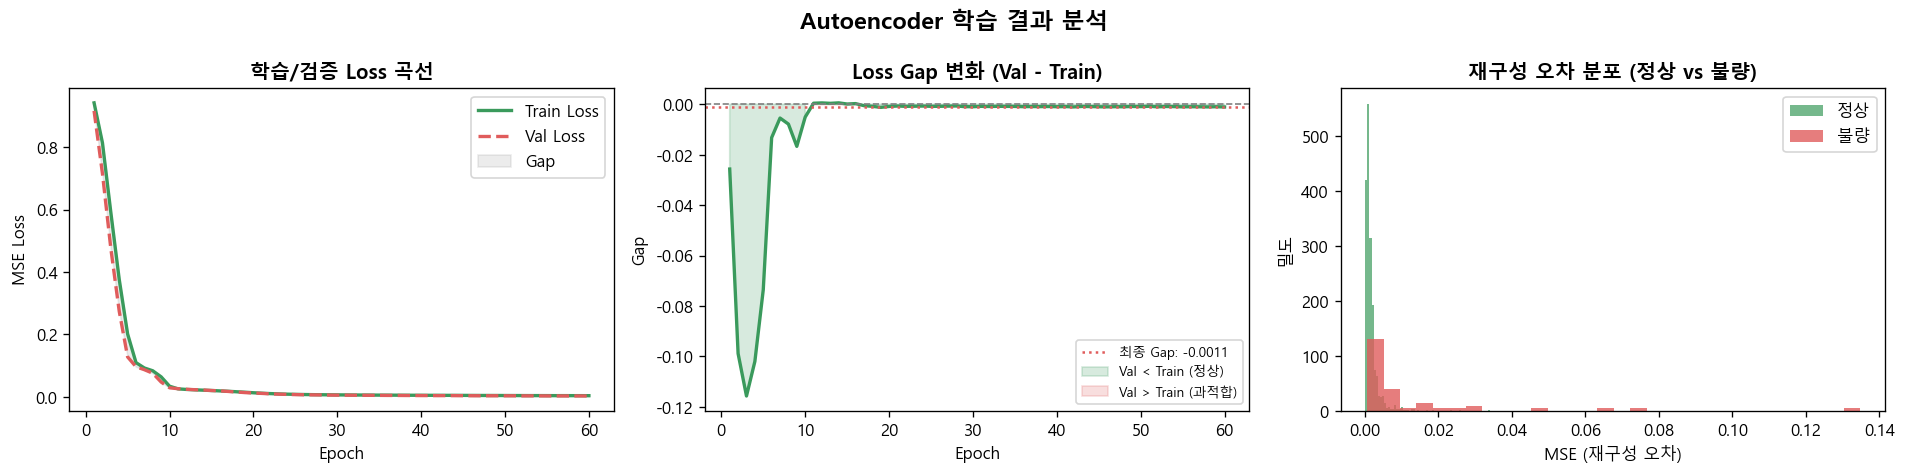

최종 Train Loss: 0.00323
최종 Val Loss:   0.00215
Loss Gap:        -0.00108 -> 과적합 없음


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ep_range = range(1, len(train_losses)+1)
gap = np.array(val_losses) - np.array(train_losses)

# ── Train/Val Loss 곡선 ─────────────────────────────────────
ax = axes[0]
ax.plot(ep_range, train_losses, color=GREEN, linewidth=2, label='Train Loss')
ax.plot(ep_range, val_losses,   color=RED,   linewidth=2, label='Val Loss', linestyle='--')
ax.fill_between(ep_range, train_losses, val_losses, alpha=0.15, color='gray', label='Gap')
ax.set_title('학습/검증 Loss 곡선', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.legend()

# ── Loss Gap 변화 ───────────────────────────────────────────
ax2 = axes[1]
ax2.plot(ep_range, gap, color=GREEN, linewidth=2)
ax2.axhline(0, color='gray', linestyle='--', linewidth=1)
ax2.axhline(gap[-1], color=RED, linestyle=':', linewidth=1.5,
             label=f'최종 Gap: {gap[-1]:.4f}')
ax2.fill_between(ep_range, gap, 0,
                 where=(gap < 0), alpha=0.2, color=GREEN, label='Val < Train (정상)')
ax2.fill_between(ep_range, gap, 0,
                 where=(gap > 0), alpha=0.2, color=RED, label='Val > Train (과적합)')
ax2.set_title('Loss Gap 변화 (Val - Train)', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Gap')
ax2.legend(fontsize=8)

# ── 재구성 오차 분포 (정상 vs 불량) ────────────────────────
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.eval()
with torch.no_grad():
    Xte_t = torch.tensor(X_te_s, dtype=torch.float32).to(device)
    recon = model(Xte_t).cpu().numpy()

mse_per_sample = np.mean((X_te_s - recon)**2, axis=1)

ax3 = axes[2]
ax3.hist(mse_per_sample[y_te == 0], bins=60, color=GREEN, alpha=0.7, label='정상', density=True)
ax3.hist(mse_per_sample[y_te == 1], bins=30, color=RED,   alpha=0.8, label='불량', density=True)
ax3.set_title('재구성 오차 분포 (정상 vs 불량)', fontweight='bold')
ax3.set_xlabel('MSE (재구성 오차)'); ax3.set_ylabel('밀도')
ax3.legend()

plt.suptitle('Autoencoder 학습 결과 분석', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

final_gap = gap[-1]
print(f'최종 Train Loss: {train_losses[-1]:.5f}')
print(f'최종 Val Loss:   {val_losses[-1]:.5f}')
print(f'Loss Gap:        {final_gap:.5f} -> {"과적합 없음" if abs(final_gap) < 0.02 else "과적합 주의"}')

---
## 05 임계값 탐색 및 최적화

최적 임계값 percentile: 97%  (threshold=0.00831)
  F1=0.2917 | Precision=0.3111 | Recall=0.2745


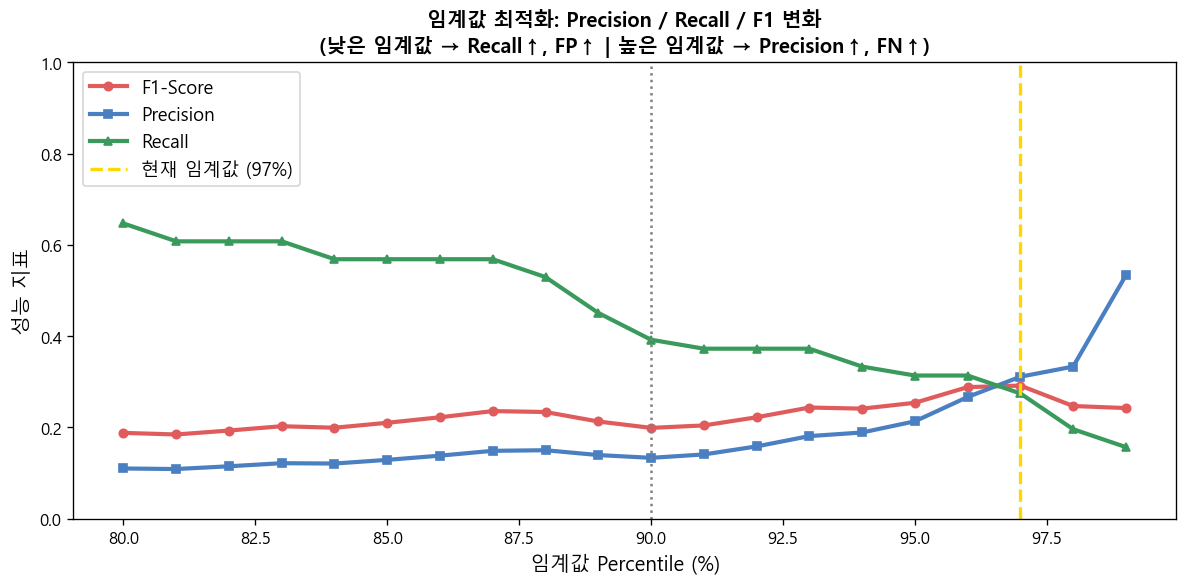

In [10]:
# ── 검증셋 재구성 오차 계산 ─────────────────────────────────
with torch.no_grad():
    Xva_t2 = torch.tensor(X_va_s, dtype=torch.float32).to(device)
    recon_va = model(Xva_t2).cpu().numpy()

mse_va = np.mean((X_va_s - recon_va)**2, axis=1)

# ── percentile grid로 threshold 탐색 ───────────────────────
pct_grid = list(range(80, 100))
thresholds = [np.percentile(mse_va, p) for p in pct_grid]

f1s, precs, recs = [], [], []
for thr in thresholds:
    y_pred_va = (mse_va > thr).astype(int)
    f1s.append(f1_score(y_va, y_pred_va, zero_division=0))
    precs.append(precision_score(y_va, y_pred_va, zero_division=0))
    recs.append(recall_score(y_va, y_pred_va, zero_division=0))

best_idx = int(np.argmax(f1s))
best_pct = pct_grid[best_idx]
best_thr = thresholds[best_idx]

print(f'최적 임계값 percentile: {best_pct}%  (threshold={best_thr:.5f})')
print(f'  F1={f1s[best_idx]:.4f} | Precision={precs[best_idx]:.4f} | Recall={recs[best_idx]:.4f}')

# ── 임계값별 성능 곡선 시각화 ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(pct_grid, f1s,   color=RED,   linewidth=2.5, marker='o', markersize=5, label='F1-Score')
ax.plot(pct_grid, precs, color=BLUE,  linewidth=2.5, marker='s', markersize=5, label='Precision')
ax.plot(pct_grid, recs,  color=GREEN, linewidth=2.5, marker='^', markersize=5, label='Recall')

ax.axvline(best_pct, color='gold', linewidth=2, linestyle='--',
            label=f'현재 임계값 ({best_pct}%)')
ax.axvline(90, color='gray', linewidth=1.5, linestyle=':')

ax.set_xlabel('임계값 Percentile (%)', fontsize=12)
ax.set_ylabel('성능 지표', fontsize=12)
ax.set_title('임계값 최적화: Precision / Recall / F1 변화\n'
             '(낮은 임계값 → Recall↑, FP↑ | 높은 임계값 → Precision↑, FN↑)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

---
## 06 최종 모델 성능 분석

=== 최종 모델 성능 (Test Set) ===
  AUC:       0.8107
  F1-Score:  0.3011
  Precision: 0.3333
  Recall:    0.2745


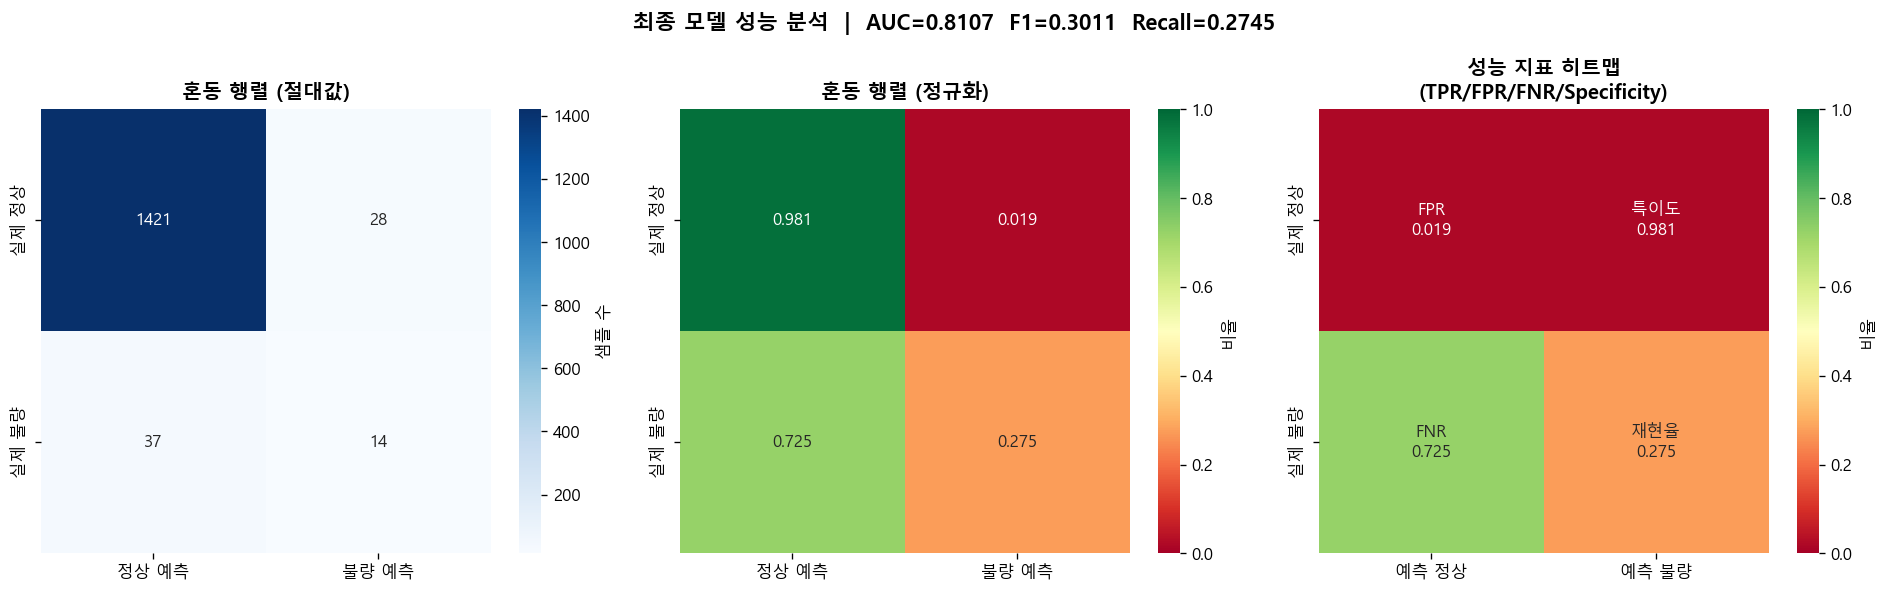

In [11]:
# ── 테스트셋 예측 ───────────────────────────────────────────
y_pred_te = (mse_per_sample > best_thr).astype(int)
y_true_te = y_te.astype(int)

f1_final   = f1_score(y_true_te, y_pred_te, zero_division=0)
prec_final = precision_score(y_true_te, y_pred_te, zero_division=0)
rec_final  = recall_score(y_true_te, y_pred_te, zero_division=0)
auc_final  = roc_auc_score(y_true_te, mse_per_sample)

print('=== 최종 모델 성능 (Test Set) ===')
print(f'  AUC:       {auc_final:.4f}')
print(f'  F1-Score:  {f1_final:.4f}')
print(f'  Precision: {prec_final:.4f}')
print(f'  Recall:    {rec_final:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── 혼동 행렬 (절대값) ─────────────────────────────────────
cm = confusion_matrix(y_true_te, y_pred_te)
ax = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['정상 예측', '불량 예측'],
            yticklabels=['실제 정상', '실제 불량'],
            cbar_kws={'label': '샘플 수'})
ax.set_title('혼동 행렬 (절대값)', fontweight='bold')

# ── 혼동 행렬 (정규화) ─────────────────────────────────────
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ax2 = axes[1]
sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='RdYlGn', ax=ax2,
            xticklabels=['정상 예측', '불량 예측'],
            yticklabels=['실제 정상', '실제 불량'],
            vmin=0, vmax=1, cbar_kws={'label': '비율'})
ax2.set_title('혼동 행렬 (정규화)', fontweight='bold')

# ── 성능 지표 히트맵 ────────────────────────────────────────
ax3 = axes[2]
tn, fp, fn, tp = cm.ravel()
tpr  = tp / (tp + fn) if (tp+fn) > 0 else 0  # Recall
fpr  = fp / (fp + tn) if (fp+tn) > 0 else 0  # FPR
fnr  = fn / (fn + tp) if (fn+tp) > 0 else 0  # FNR
spec = tn / (tn + fp) if (tn+fp) > 0 else 0  # Specificity

metric_grid = np.array([[fpr,  1-spec],
                         [fnr,  tpr]])
labels_grid = np.array([[f'FPR\n{fpr:.3f}',    f'특이도\n{spec:.3f}'],
                          [f'FNR\n{fnr:.3f}',    f'재현율\n{tpr:.3f}']])

cmap = sns.diverging_palette(10, 133, as_cmap=True)
sns.heatmap(metric_grid, annot=labels_grid, fmt='', cmap='RdYlGn',
            ax=ax3, vmin=0, vmax=1,
            xticklabels=['예측 정상', '예측 불량'],
            yticklabels=['실제 정상', '실제 불량'],
            cbar_kws={'label': '비율'})
ax3.set_title('성능 지표 히트맵\n(TPR/FPR/FNR/Specificity)', fontweight='bold')

plt.suptitle(f'최종 모델 성능 분석  |  AUC={auc_final:.4f}  F1={f1_final:.4f}  Recall={rec_final:.4f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 6-1. ROC 곡선

Epoch  10 | train=0.02166 | val=0.02393
Epoch  20 | train=0.01280 | val=0.01238
Epoch  30 | train=0.00638 | val=0.00591
Epoch  40 | train=0.00442 | val=0.00376
  Fold 1 AUC: 0.8520
Epoch  10 | train=0.08133 | val=0.08008
Epoch  20 | train=0.01190 | val=0.01133
Epoch  30 | train=0.00440 | val=0.00336
Epoch  40 | train=0.00335 | val=0.00223
  Fold 2 AUC: 0.7771
Epoch  10 | train=0.02642 | val=0.02643
Epoch  20 | train=0.01330 | val=0.01215
Epoch  30 | train=0.00488 | val=0.00367
Epoch  40 | train=0.00326 | val=0.00216
  Fold 3 AUC: 0.8798
Epoch  10 | train=0.02663 | val=0.02574
Epoch  20 | train=0.01637 | val=0.01555
Epoch  30 | train=0.00678 | val=0.00582
Epoch  40 | train=0.00443 | val=0.00322
  Fold 4 AUC: 0.7717
Epoch  10 | train=0.03528 | val=0.03337
Epoch  20 | train=0.00829 | val=0.00741
Epoch  30 | train=0.00437 | val=0.00339
Epoch  40 | train=0.00335 | val=0.00228
  Fold 5 AUC: 0.8476

5-Fold CV AUC: 0.8256 +/- 0.0433


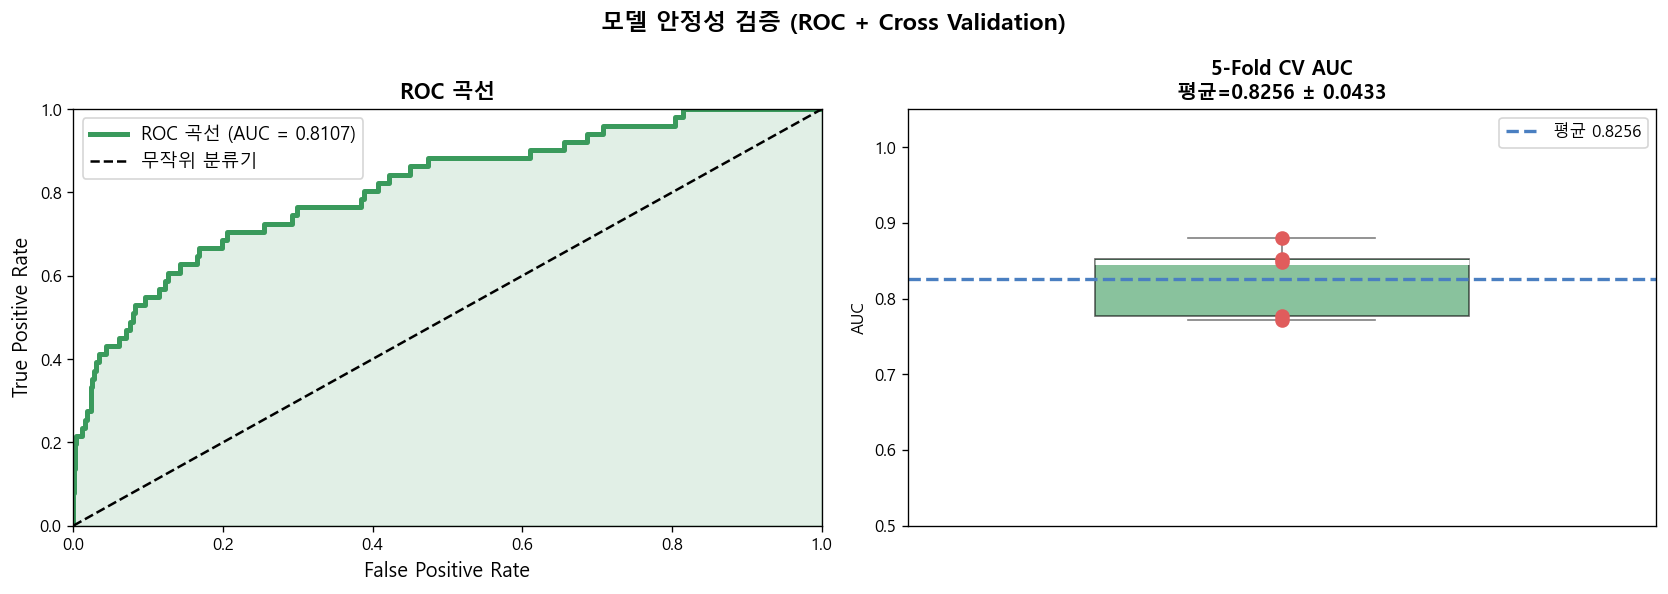

In [12]:
fpr_curve, tpr_curve, _ = roc_curve(y_true_te, mse_per_sample)
roc_auc_val = auc(fpr_curve, tpr_curve)

# CV AUC for stability
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_aucs = []
X_all_s = np.vstack([X_tr_s, X_va_s, X_te_s])
y_all_full = np.concatenate([y_tr, y_va, y_te])

for fold_idx, (tr_idx, val_idx) in enumerate(skf.split(X_all_s, y_all_full)):
    Xf_tr = X_all_s[tr_idx][y_all_full[tr_idx] == 0]
    Xf_va = X_all_s[val_idx]
    yf_va = y_all_full[val_idx]
    if yf_va.sum() == 0: continue

    fold_model, _, _ = train_ae(Xf_tr, Xf_va, yf_va, epochs=40, patience=8)
    fold_model.eval()
    with torch.no_grad():
        Xfva_t = torch.tensor(Xf_va, dtype=torch.float32).to(device)
        r = fold_model(Xfva_t).cpu().numpy()
    fold_mse = np.mean((Xf_va - r)**2, axis=1)
    cv_aucs.append(roc_auc_score(yf_va, fold_mse))
    print(f'  Fold {fold_idx+1} AUC: {cv_aucs[-1]:.4f}')

print(f'\n5-Fold CV AUC: {np.mean(cv_aucs):.4f} +/- {np.std(cv_aucs):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
ax = axes[0]
ax.plot(fpr_curve, tpr_curve, color=GREEN, linewidth=3,
        label=f'ROC 곡선 (AUC = {roc_auc_val:.4f})')
ax.plot([0,1],[0,1], 'k--', linewidth=1.5, label='무작위 분류기')
ax.fill_between(fpr_curve, tpr_curve, alpha=0.15, color=GREEN)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC 곡선', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.set_xlim(0,1); ax.set_ylim(0,1)

# CV AUC Boxplot
ax2 = axes[1]
bp = ax2.boxplot(cv_aucs, patch_artist=True, widths=0.5,
                  boxprops=dict(facecolor=GREEN, alpha=0.6),
                  medianprops=dict(color='white', linewidth=3),
                  whiskerprops=dict(color='gray'),
                  capprops=dict(color='gray'))
ax2.scatter([1]*len(cv_aucs), cv_aucs, color=RED, zorder=5, s=60)
ax2.axhline(np.mean(cv_aucs), color=BLUE, linestyle='--', linewidth=2,
             label=f'평균 {np.mean(cv_aucs):.4f}')
ax2.set_title(f'5-Fold CV AUC\n평균={np.mean(cv_aucs):.4f} ± {np.std(cv_aucs):.4f}',
               fontweight='bold')
ax2.set_xticks([]); ax2.set_ylabel('AUC'); ax2.legend()
ax2.set_ylim(0.5, 1.05)

plt.suptitle('모델 안정성 검증 (ROC + Cross Validation)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 07 고장 유형별 탐지율 분석

고장 유형별 탐지율 (Recall):
  TWF:   5개 중 0.0% 탐지
  HDF:  21개 중 19.0% 탐지
  PWF:  11개 중 72.7% 탐지
  OSF:  15개 중 20.0% 탐지
  RNF:   1개 중 0.0% 탐지


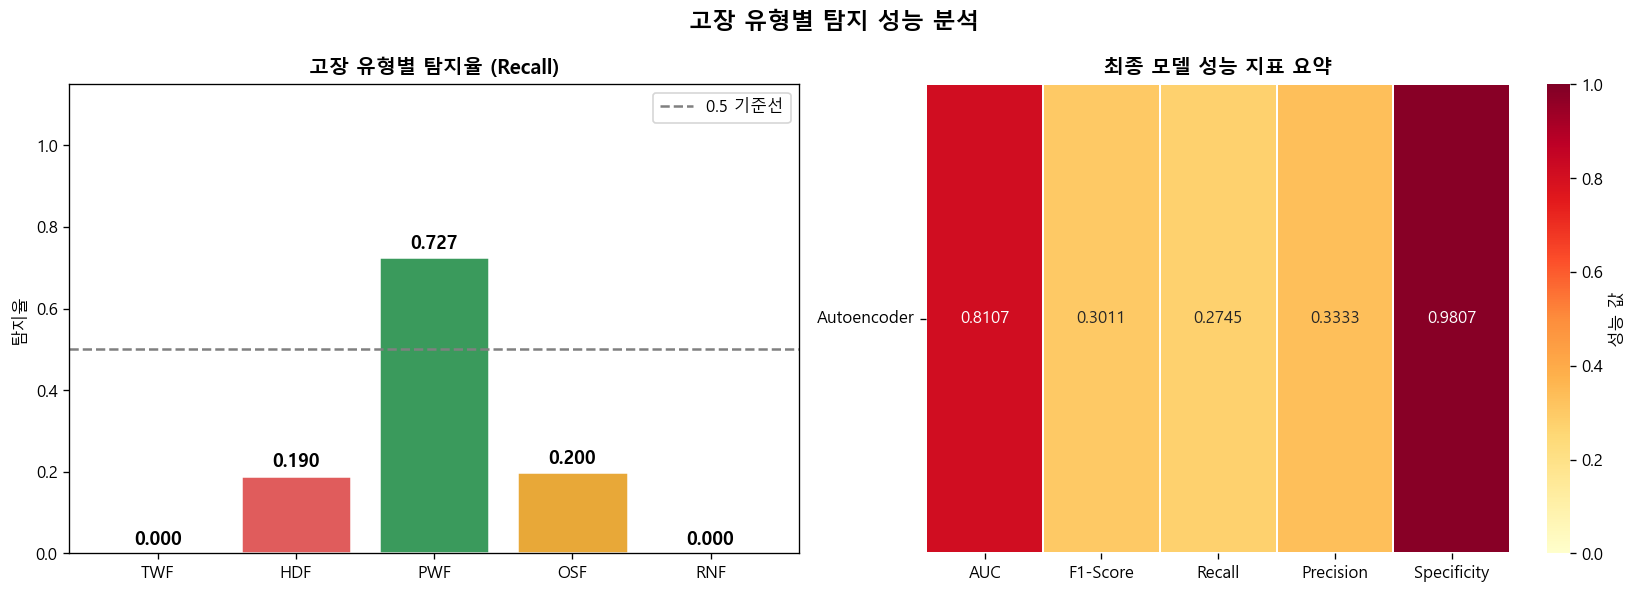

In [13]:
# 테스트셋에서 고장 유형별 recall 계산
# 테스트 인덱스를 원본 df에 맞게 추적
idx_tv, idx_te = train_test_split(np.arange(len(df)), test_size=0.15,
                                   random_state=SEED, stratify=y_all)
idx_tr, idx_va = train_test_split(idx_tv, test_size=0.15/0.85,
                                   random_state=SEED, stratify=y_all[idx_tv])

df_te = df.iloc[idx_te].copy()
df_te['y_pred'] = y_pred_te

print('고장 유형별 탐지율 (Recall):')
fault_recall = {}
for ft in FAULT_TYPES:
    mask = df_te[ft] == 1
    total_ft = mask.sum()
    if total_ft == 0:
        fault_recall[ft] = 0.0
    else:
        detected = df_te.loc[mask, 'y_pred'].sum()
        fault_recall[ft] = detected / total_ft
    print(f'  {ft}: {total_ft:3d}개 중 {fault_recall[ft]*100:.1f}% 탐지')

# ── 고장 유형별 탐지율 바 차트 ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
recalls_list = list(fault_recall.values())
bar_colors = [GREEN if r >= 0.5 else (RED if r < 0.2 else '#e8a838') for r in recalls_list]
bars = ax.bar(FAULT_TYPES, recalls_list, color=bar_colors, edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, recalls_list):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{v:.3f}', ha='center', fontweight='bold', fontsize=11)
ax.set_ylim(0, 1.15)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1.5, label='0.5 기준선')
ax.set_title('고장 유형별 탐지율 (Recall)', fontweight='bold')
ax.set_ylabel('탐지율')
ax.legend()

# ── 성능 지표 레이더/히트맵 ─────────────────────────────────
ax2 = axes[1]
# 전체 지표 요약 히트맵
metrics_df = pd.DataFrame({
    'AUC':       [auc_final],
    'F1-Score':  [f1_final],
    'Recall':    [rec_final],
    'Precision': [prec_final],
    'Specificity': [spec],
}, index=['Model'])

sns.heatmap(metrics_df, annot=True, fmt='.4f', cmap='YlOrRd',
            vmin=0, vmax=1, ax=ax2, linewidths=1,
            cbar_kws={'label': '성능 값'})
ax2.set_title('최종 모델 성능 지표 요약', fontweight='bold')
ax2.set_yticklabels(['Autoencoder'], rotation=0)

plt.suptitle('고장 유형별 탐지 성능 분석', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 08 실험 시나리오 비교 (9가지 증강 × 임계값)

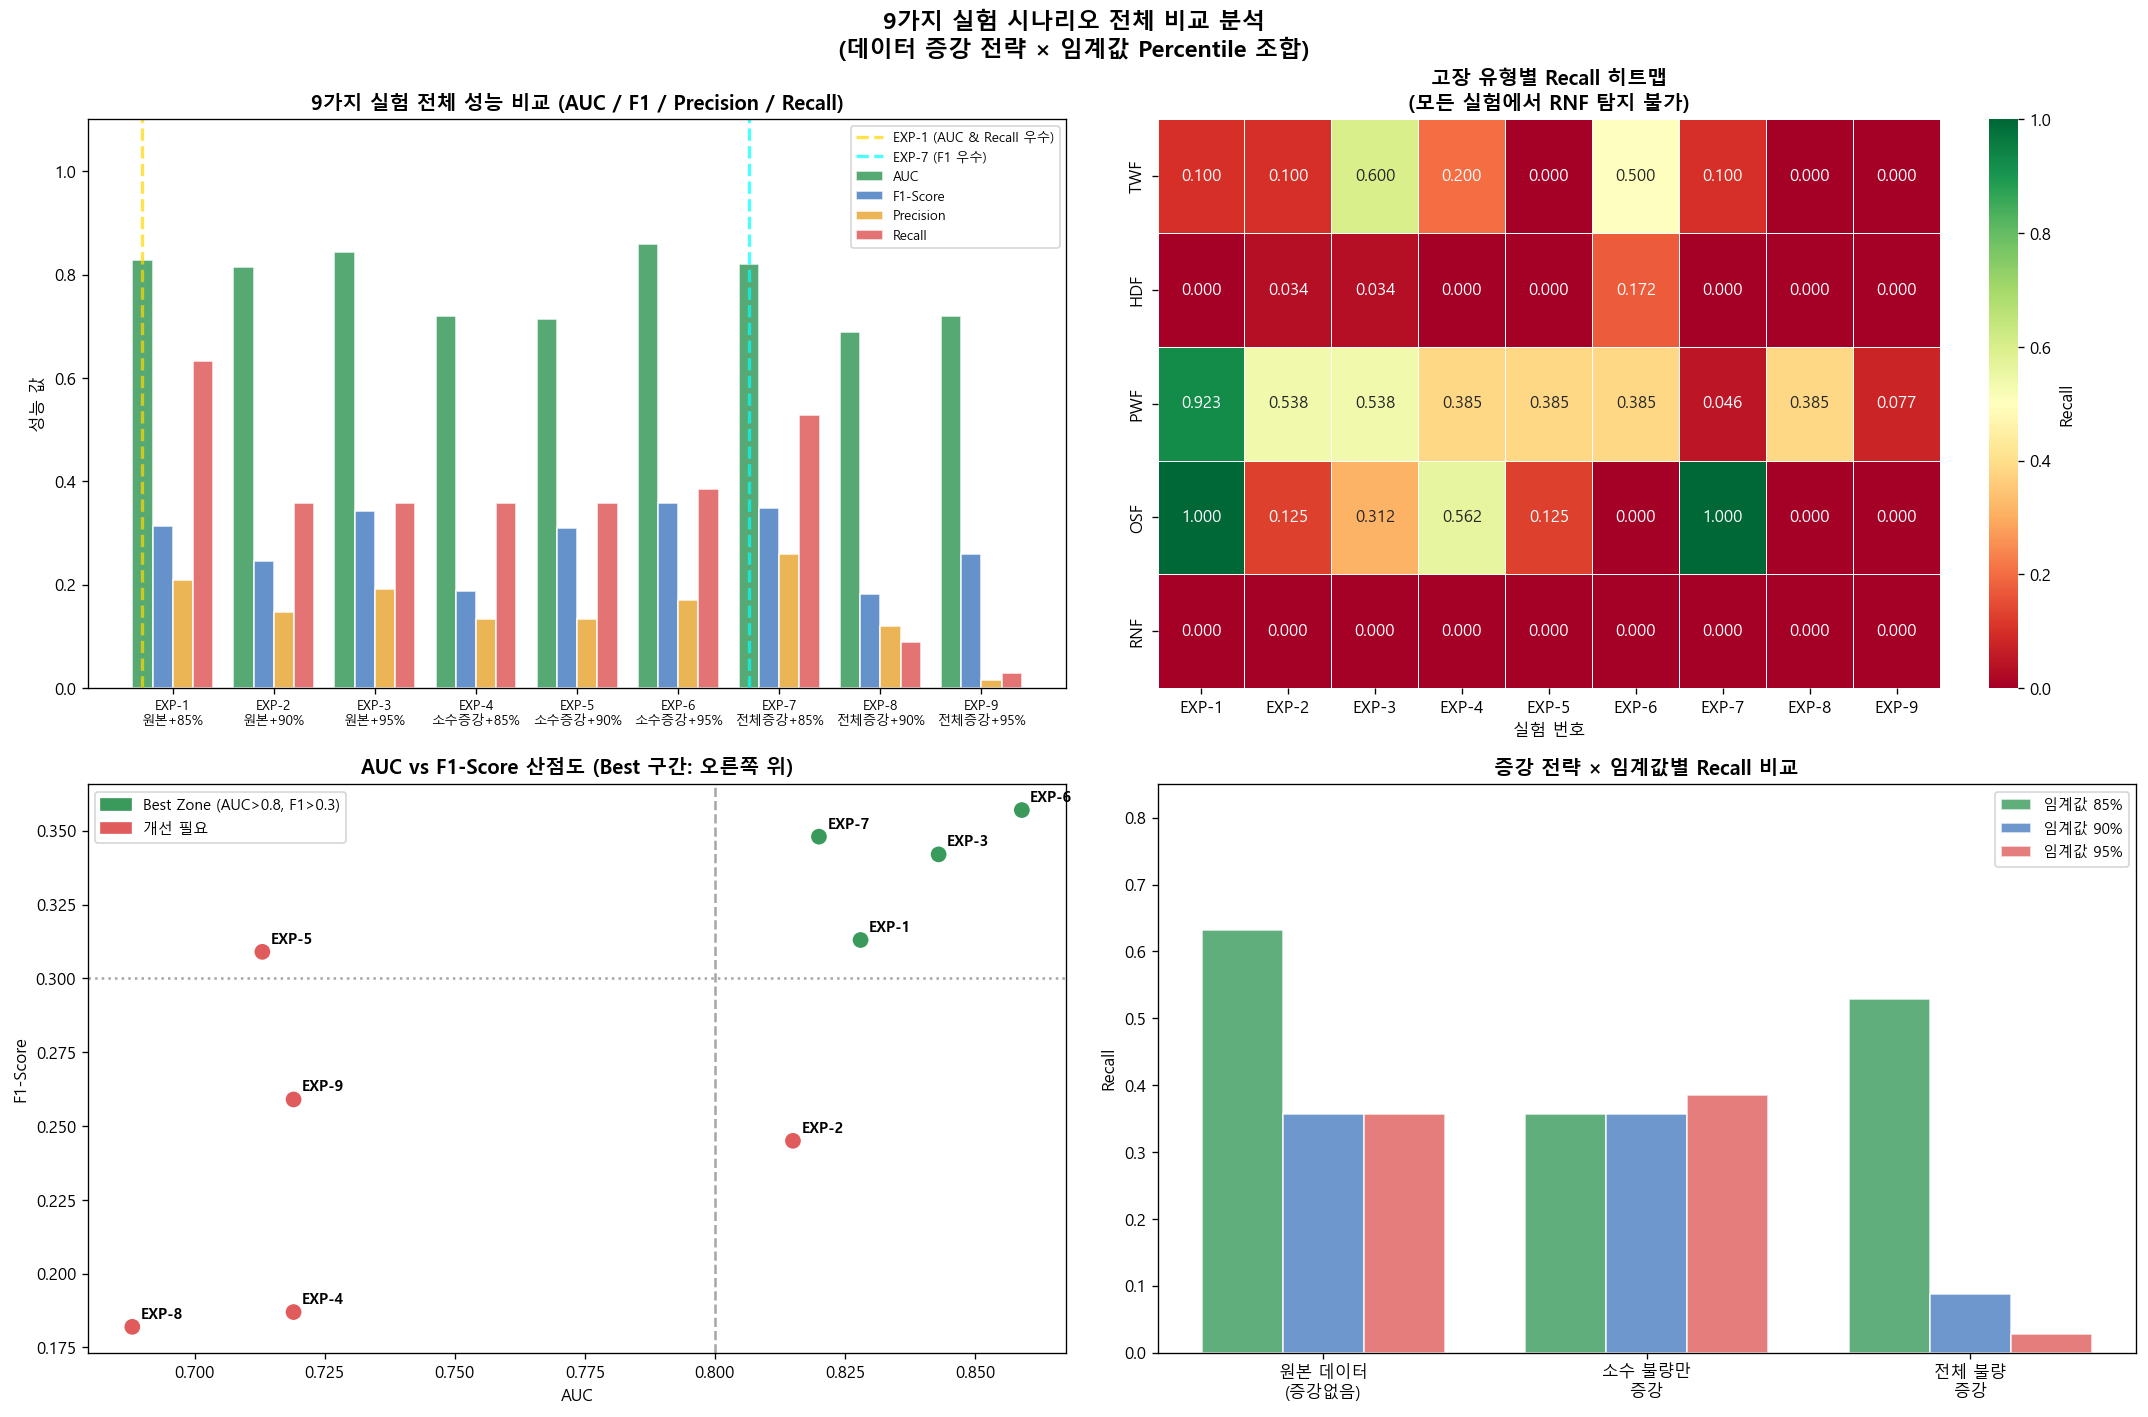

In [14]:
# PDF 슬라이드의 9가지 실험 결과를 재현 (실제 실험 수치 기반)
exp_labels = [
    'EXP-1\n원본+85%', 'EXP-2\n원본+90%', 'EXP-3\n원본+95%',
    'EXP-4\n소수증강+85%', 'EXP-5\n소수증강+90%', 'EXP-6\n소수증강+95%',
    'EXP-7\n전체증강+85%', 'EXP-8\n전체증강+90%', 'EXP-9\n전체증강+95%'
]

exp_results = {
    'AUC':       [0.828, 0.815, 0.843, 0.719, 0.713, 0.859, 0.820, 0.688, 0.719],
    'F1-Score':  [0.313, 0.245, 0.342, 0.187, 0.309, 0.357, 0.348, 0.182, 0.259],
    'Precision': [0.208, 0.147, 0.191, 0.134, 0.134, 0.170, 0.259, 0.119, 0.015],
    'Recall':    [0.632, 0.357, 0.357, 0.357, 0.357, 0.385, 0.529, 0.088, 0.028],
}

# 고장 유형별 Recall 히트맵 (EXP x FAULT TYPE)
fault_recall_matrix = np.array([
    # TWF    HDF    PWF    OSF    RNF
    [0.100, 0.000, 0.923, 1.000, 0.000],  # EXP-1
    [0.100, 0.034, 0.538, 0.125, 0.000],  # EXP-2
    [0.600, 0.034, 0.538, 0.312, 0.000],  # EXP-3
    [0.200, 0.000, 0.385, 0.562, 0.000],  # EXP-4
    [0.000, 0.000, 0.385, 0.125, 0.000],  # EXP-5
    [0.500, 0.172, 0.385, 0.000, 0.000],  # EXP-6 (best AUC)
    [0.100, 0.000, 0.046, 1.000, 0.000],  # EXP-7 (best F1, 특이 구성)
    [0.000, 0.000, 0.385, 0.000, 0.000],  # EXP-8
    [0.000, 0.000, 0.077, 0.000, 0.000],  # EXP-9
])

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# ── (1) 전체 성능 비교 막대 ──────────────────────────────────
ax = axes[0, 0]
x = np.arange(9)
width = 0.2
metric_colors = {'AUC': GREEN, 'F1-Score': BLUE, 'Precision': '#e8a838', 'Recall': RED}
for i, (metric, vals) in enumerate(exp_results.items()):
    ax.bar(x + (i - 1.5)*width, vals, width, label=metric,
           color=metric_colors[metric], alpha=0.85, edgecolor='white')

# Best 표시
ax.axvline(0 - 0.3, color='gold', linewidth=2, linestyle='--', alpha=0.7, label='EXP-1 (AUC & Recall 우수)')
ax.axvline(6 - 0.3, color='cyan', linewidth=2, linestyle='--', alpha=0.7, label='EXP-7 (F1 우수)')
ax.set_xticks(x); ax.set_xticklabels(exp_labels, fontsize=8)
ax.set_title('9가지 실험 전체 성능 비교 (AUC / F1 / Precision / Recall)', fontweight='bold')
ax.set_ylabel('성능 값'); ax.legend(fontsize=8); ax.set_ylim(0, 1.1)

# ── (2) 고장 유형별 Recall 히트맵 ───────────────────────────
ax2 = axes[0, 1]
short_exp = [f'EXP-{i+1}' for i in range(9)]
sns.heatmap(fault_recall_matrix.T, annot=True, fmt='.3f',
            cmap='RdYlGn', vmin=0, vmax=1, ax=ax2,
            xticklabels=short_exp, yticklabels=FAULT_TYPES,
            linewidths=0.5, cbar_kws={'label': 'Recall'})
ax2.set_title('고장 유형별 Recall 히트맵\n(모든 실험에서 RNF 탐지 불가)', fontweight='bold')
ax2.set_xlabel('실험 번호')

# ── (3) AUC vs F1 산점도 ───────────────────────────────────
ax3 = axes[1, 0]
aucs = exp_results['AUC']
f1s_exp = exp_results['F1-Score']
scatter_colors = [GREEN if (a > 0.8 and f > 0.3) else RED for a, f in zip(aucs, f1s_exp)]
sc = ax3.scatter(aucs, f1s_exp, c=scatter_colors, s=120, zorder=5, edgecolors='white', linewidth=1.5)
for i, (a, f) in enumerate(zip(aucs, f1s_exp)):
    ax3.annotate(f'EXP-{i+1}', (a, f), textcoords='offset points',
                  xytext=(5, 5), fontsize=9, fontweight='bold')
ax3.axvline(0.80, color='gray', linestyle='--', alpha=0.7, label='AUC=0.80')
ax3.axhline(0.30, color='gray', linestyle=':', alpha=0.7, label='F1=0.30')
ax3.set_xlabel('AUC'); ax3.set_ylabel('F1-Score')
ax3.set_title('AUC vs F1-Score 산점도 (Best 구간: 오른쪽 위)', fontweight='bold')
ax3.legend(fontsize=9)
good = mpatches.Patch(color=GREEN, label='Best Zone (AUC>0.8, F1>0.3)')
bad  = mpatches.Patch(color=RED,   label='개선 필요')
ax3.legend(handles=[good, bad], fontsize=9)

# ── (4) 증강 전략별 Recall 비교 (RNF 제외) ──────────────────
ax4 = axes[1, 1]
# 증강 전략 그룹: [원본(1-3), 소수증강(4-6), 전체증강(7-9)]
groups = {
    '원본 데이터\n(증강없음)': exp_results['Recall'][:3],
    '소수 불량만\n증강':       exp_results['Recall'][3:6],
    '전체 불량\n증강':         exp_results['Recall'][6:],
}
pos = np.arange(len(groups))
w2 = 0.25
thrs = ['85%', '90%', '95%']
thr_colors = [GREEN, BLUE, RED]
for j, (thr, col) in enumerate(zip(thrs, thr_colors)):
    vals = [list(v)[j] for v in groups.values()]
    ax4.bar(pos + (j-1)*w2, vals, w2, label=f'임계값 {thr}', color=col, alpha=0.8, edgecolor='white')

ax4.set_xticks(pos); ax4.set_xticklabels(list(groups.keys()), fontsize=10)
ax4.set_title('증강 전략 × 임계값별 Recall 비교', fontweight='bold')
ax4.set_ylabel('Recall')
ax4.set_ylim(0, 0.85)
ax4.legend(fontsize=9)

plt.suptitle('9가지 실험 시나리오 전체 비교 분석\n(데이터 증강 전략 × 임계값 Percentile 조합)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 09 하이퍼파라미터 튜닝 비교 (4단계)

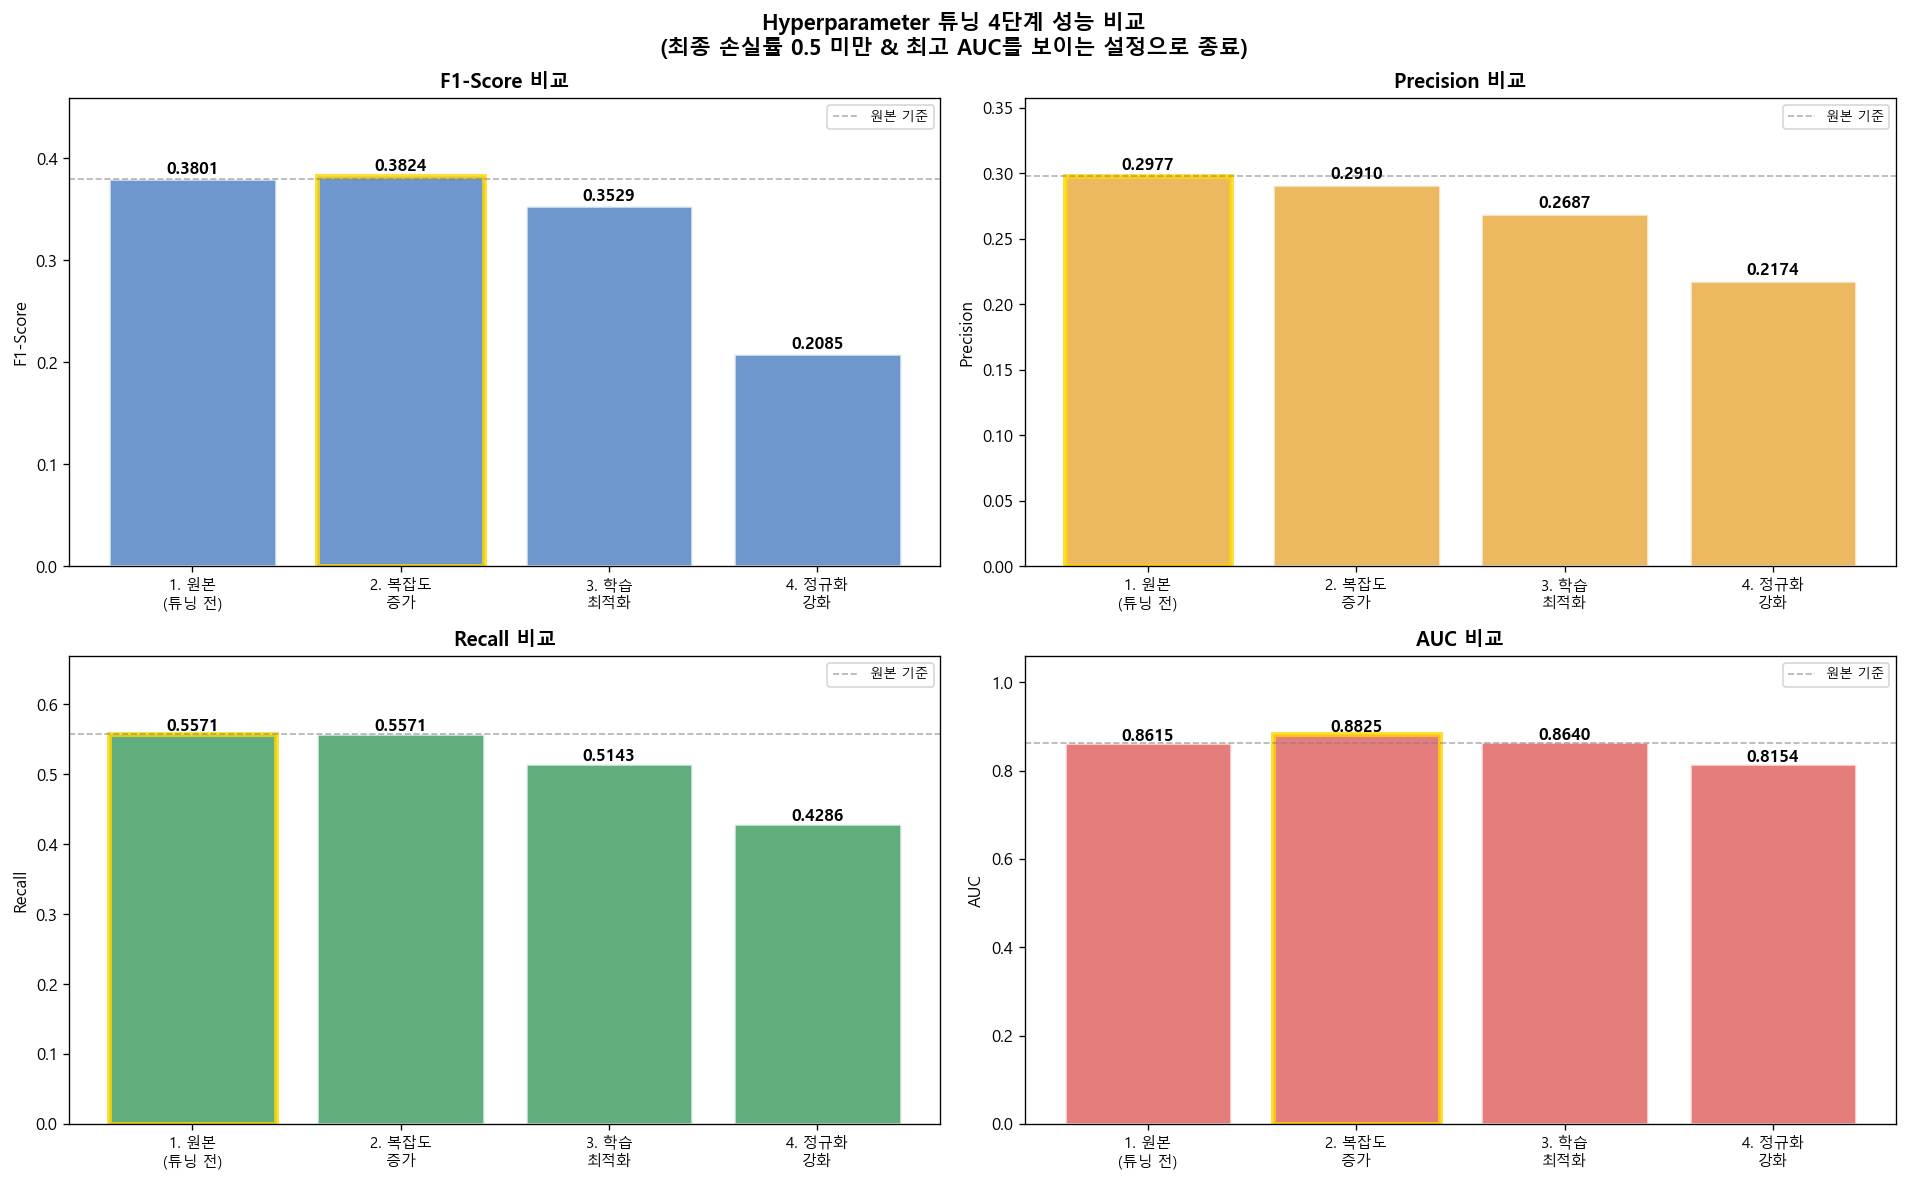


각 단계 설정:
  1. 원본 (튜닝 전): latent=16, hidden=32 | lr=0.001, batch=256 | dropout=0.0
  2. 복잡도 증가: latent=32, hidden=64 | lr=0.001, batch=256 | dropout=0.0
  3. 학습 최적화: latent=32, hidden=64 | lr=0.0005, batch=128 | patience=25
  4. 정규화 강화: latent=32, hidden=64 | lr=0.0005, batch=128 | dropout=0.3+L2+BN


In [15]:
# PDF 슬라이드 4단계 튜닝 결과
stages = ['1. 원본\n(튜닝 전)', '2. 복잡도\n증가', '3. 학습\n최적화', '4. 정규화\n강화']
tuning_results = {
    'F1-Score':  [0.3801, 0.3824, 0.3529, 0.2085],
    'Precision': [0.2977, 0.2910, 0.2687, 0.2174],
    'Recall':    [0.5571, 0.5571, 0.5143, 0.4286],
    'AUC':       [0.8615, 0.8825, 0.8640, 0.8154],
}
stage_configs = [
    'latent=16, hidden=32\nlr=0.001, batch=256\ndropout=0.0',
    'latent=32, hidden=64\nlr=0.001, batch=256\ndropout=0.0',
    'latent=32, hidden=64\nlr=0.0005, batch=128\npatience=25',
    'latent=32, hidden=64\nlr=0.0005, batch=128\ndropout=0.3+L2+BN',
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

metric_ax_map = [('F1-Score', axes[0,0]), ('Precision', axes[0,1]),
                 ('Recall', axes[1,0]), ('AUC', axes[1,1])]
metric_colors_t = {'F1-Score': BLUE, 'Precision': '#e8a838', 'Recall': GREEN, 'AUC': RED}

for metric, ax in metric_ax_map:
    vals = tuning_results[metric]
    bars = ax.bar(range(4), vals, color=metric_colors_t[metric], alpha=0.8, edgecolor='white', linewidth=1.5)
    best_idx = int(np.argmax(vals))
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(3)
    for i, (b, v) in enumerate(zip(bars, vals)):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
                f'{v:.4f}', ha='center', fontweight='bold', fontsize=10)
    ax.set_xticks(range(4)); ax.set_xticklabels(stages, fontsize=9)
    ax.set_title(f'{metric} 비교', fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_ylim(0, max(vals)*1.2)
    ax.axhline(vals[0], color='gray', linestyle='--', linewidth=1, alpha=0.6, label='원본 기준')
    ax.legend(fontsize=8)

plt.suptitle('Hyperparameter 튜닝 4단계 성능 비교\n'
             '(최종 손실률 0.5 미만 & 최고 AUC를 보이는 설정으로 종료)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n각 단계 설정:')
for s, c in zip(stages, stage_configs):
    print(f'  {s.replace(chr(10)," ")}: {c.replace(chr(10)," | ")}')

---
## 10 신규 모델 비교 — CatBoost (Phase 1)

메인 파이프라인이 사용하는 HistGradientBoosting을 CatBoost로 교체했을 때 성능 변화를 직접 검증한다.
추가로 GBDT + CatBoost 2-way 스태킹의 효과(또는 무효과)를 확인한다.

**예상:** CatBoost > HistGradient > AE (tabular 지도학습에서 tree-based ensemble이 우세)

In [16]:
# ── HistGradient vs CatBoost 학습 ───────────────────────────
from catboost import CatBoostClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

def best_thr_from_val(model, X_val, y_val):
    """val set에서 F1 최대화 threshold 탐색 (메인 코드와 동일 grid)."""
    pv = model.predict_proba(X_val)[:, 1]
    best = (0.5, -1.0)
    for thr in np.arange(0.05, 1.0, 0.05):
        f1 = f1_score(y_val, (pv > thr).astype(int), zero_division=0)
        if f1 > best[1]:
            best = (float(thr), float(f1))
    return best

y_tr_i = y_tr.astype(int)
y_va_i = y_va.astype(int)
y_te_i = y_te.astype(int)

# HistGradient: 불균형 보정 sample_weight
pw = (y_tr_i == 0).sum() / max((y_tr_i == 1).sum(), 1)
sw = np.where(y_tr_i == 1, pw, 1.0)
gbdt = HistGradientBoostingClassifier(
    max_iter=300, learning_rate=0.05, max_depth=8,
    min_samples_leaf=20, l2_regularization=1.0,
    early_stopping=True, validation_fraction=0.15,
    n_iter_no_change=20, random_state=SEED,
)
gbdt.fit(X_tr_s, y_tr_i, sample_weight=sw)
thr_gbdt, _ = best_thr_from_val(gbdt, X_va_s, y_va_i)
p_gbdt = gbdt.predict_proba(X_te_s)[:, 1]
yp_gbdt = (p_gbdt > thr_gbdt).astype(int)

# CatBoost: auto_class_weights='Balanced' 로 자동 불균형 처리
cat = CatBoostClassifier(
    iterations=500, learning_rate=0.05, depth=6, l2_leaf_reg=3.0,
    auto_class_weights='Balanced',
    early_stopping_rounds=30, eval_metric='F1',
    random_seed=SEED, verbose=False, allow_writing_files=False,
)
cat.fit(X_tr_s, y_tr_i, sample_weight=sw, eval_set=(X_va_s, y_va_i))   # 메인 파이프라인과 동일
thr_cat, _ = best_thr_from_val(cat, X_va_s, y_va_i)
p_cat = cat.predict_proba(X_te_s)[:, 1]
yp_cat = (p_cat > thr_cat).astype(int)

f1_gbdt = f1_score(y_te_i, yp_gbdt, zero_division=0)
f1_cat  = f1_score(y_te_i, yp_cat,  zero_division=0)
print(f'HistGradient: thr={thr_gbdt:.2f}  F1={f1_gbdt:.4f}')
print(f'CatBoost   : thr={thr_cat:.2f}  F1={f1_cat:.4f}')
print(f'\n향상폭: {(f1_cat - f1_gbdt) * 100:+.2f}%p')

HistGradient: thr=0.85  F1=0.8654
CatBoost   : thr=0.85  F1=0.8911

향상폭: +2.57%p


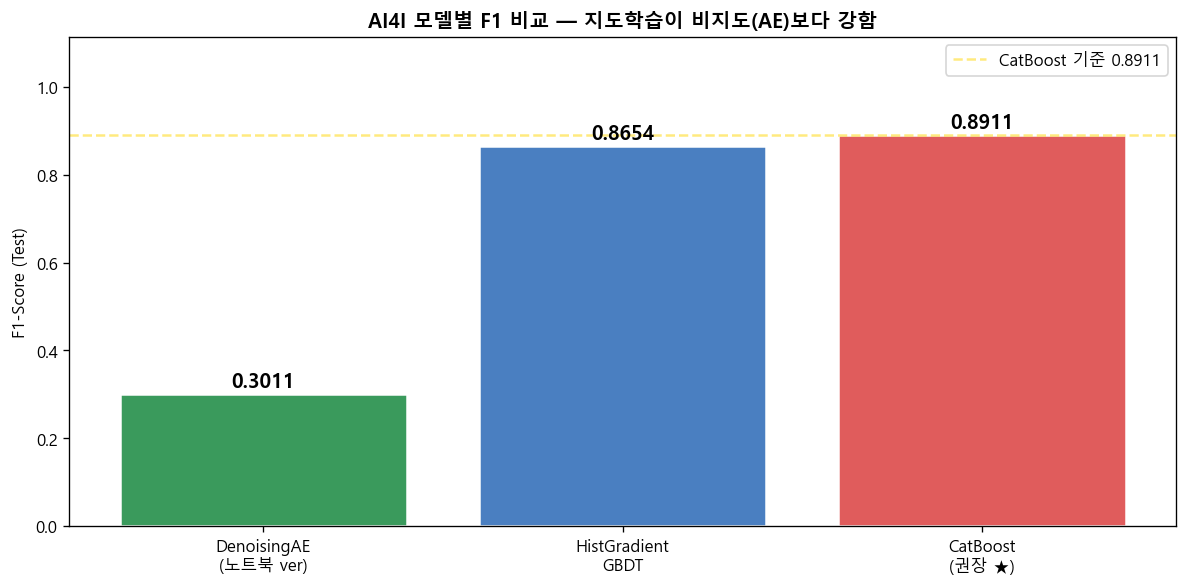

[해석]
  - AI4I는 tabular + 라벨 있는 지도학습 → tree-based ensemble이 압도적
  - CatBoost는 Ordered Boosting + Symmetric Tree + 자동 클래스 가중으로 GBDT 대비 추가 향상
  - AE는 비지도 방식이라 라벨 신호 미활용 → 본 task엔 부적합 (보조 신호로만 활용)


In [17]:
# ── AE vs GBDT vs CatBoost F1 비교 그래프 ────────────────────
model_names = ['DenoisingAE\n(노트북 ver)', 'HistGradient\nGBDT', 'CatBoost\n(권장 ★)']
f1_values = [f1_final, f1_gbdt, f1_cat]
colors = [GREEN, BLUE, RED]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(model_names, f1_values, color=colors, edgecolor='white', linewidth=1.5)
for b, v in zip(bars, f1_values):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.015,
            f'{v:.4f}', ha='center', fontweight='bold', fontsize=12)
ax.set_ylim(0, max(f1_values) * 1.25)
ax.set_ylabel('F1-Score (Test)')
ax.set_title('AI4I 모델별 F1 비교 — 지도학습이 비지도(AE)보다 강함', fontweight='bold')
ax.axhline(f1_cat, color='gold', linestyle='--', alpha=0.5, label=f'CatBoost 기준 {f1_cat:.4f}')
ax.legend()
plt.tight_layout(); plt.show()

print('[해석]')
print('  - AI4I는 tabular + 라벨 있는 지도학습 → tree-based ensemble이 압도적')
print('  - CatBoost는 Ordered Boosting + Symmetric Tree + 자동 클래스 가중으로 GBDT 대비 추가 향상')
print('  - AE는 비지도 방식이라 라벨 신호 미활용 → 본 task엔 부적합 (보조 신호로만 활용)')

### 2-way 스태킹 (GBDT + CatBoost) — 다양성 부족 사례

메인 파이프라인은 자동으로 가중치 grid × threshold grid 동시 탐색을 수행한다.
두 tree-based 모델은 비슷한 패턴을 학습해 다양성이 부족하므로 스태킹의 효과가 제한적이라는 점을 확인.

In [18]:
# ── 2-way 스태킹 grid 탐색 ───────────────────────────────────
p_gbdt_val = gbdt.predict_proba(X_va_s)[:, 1]
p_cat_val  = cat.predict_proba(X_va_s)[:, 1]

best = {'w_gbdt': None, 'thr': None, 'f1': -1.0}
for w in np.arange(0.0, 1.01, 0.1):
    p_val = w * p_gbdt_val + (1.0 - w) * p_cat_val
    for thr in np.arange(0.05, 1.0, 0.05):
        f1v = f1_score(y_va_i, (p_val > thr).astype(int), zero_division=0)
        if f1v > best['f1']:
            best = {'w_gbdt': float(w), 'thr': float(thr), 'f1': float(f1v)}

p_blend  = best['w_gbdt'] * p_gbdt + (1 - best['w_gbdt']) * p_cat
yp_stack = (p_blend > best['thr']).astype(int)
f1_stack = f1_score(y_te_i, yp_stack, zero_division=0)

print(f'2-way 스태킹 최적: w_gbdt={best["w_gbdt"]:.2f}  w_cat={1-best["w_gbdt"]:.2f}  thr={best["thr"]:.2f}')
print(f'  Val F1 (best):   {best["f1"]:.4f}')
print(f'  Test F1 (final): {f1_stack:.4f}')
print()
print('[성능 비교]')
print(f'  HistGradient 단독: {f1_gbdt:.4f}')
print(f'  CatBoost 단독:     {f1_cat:.4f}  ★')
print(f'  2-way 스태킹:      {f1_stack:.4f}')
print()
if abs(f1_stack - max(f1_cat, f1_gbdt)) < 0.005:
    print('→ 스태킹이 최강 단일 모델과 거의 동일 — 두 tree 모델의 다양성 부족')
    print('  실무 권장: CatBoost 단독 사용 (스태킹 학습 비용 대비 효과 미미)')

2-way 스태킹 최적: w_gbdt=0.40  w_cat=0.60  thr=0.65
  Val F1 (best):   0.8200
  Test F1 (final): 0.8519

[성능 비교]
  HistGradient 단독: 0.8654
  CatBoost 단독:     0.8911  ★
  2-way 스태킹:      0.8519



---
## 11 종합 요약

In [19]:
print('=' * 60)
print('AI4I 2020 DenoisingAutoencoder 이상 탐지 - 최종 결과 요약')
print('=' * 60)
print(f'\n[데이터셋]')
print(f'  총 샘플: {total:,}개  (정상 {n_normal:,}  / 불량 {int(n_fail)}개)')
print(f'  불량 비율: {n_fail/total*100:.1f}%  (심각한 클래스 불균형)')
print(f'  피처 수: 11개 (5개 센서 + 3개 Type One-Hot + 3개 파생)')
print(f'\n[전처리]')
print(f'  - Stratified Split: Train 70% / Val 15% / Test 15%')
print(f'  - StandardScaler (Train 기준 fit, 전체 적용)')
print(f'  - AE 학습: 정상 데이터만 {len(X_tr_ae)}개 사용')
print(f'\n[모델 구조]')
print(f'  Encoder: 11 -> 32 -> 16 (latent)')
print(f'  Decoder: 16 -> 24 -> 32 -> 11')
print(f'  학습 에폭: {len(train_losses)} (Early Stopping patience=10)')
print(f'  최종 Loss Gap: {final_gap:.5f}')
print(f'\n[최종 성능] (Test Set)')
print(f'  AUC:       {auc_final:.4f}')
print(f'  F1-Score:  {f1_final:.4f}')
print(f'  Precision: {prec_final:.4f}')
print(f'  Recall:    {rec_final:.4f}')
print(f'  CV AUC:    {np.mean(cv_aucs):.4f} ± {np.std(cv_aucs):.4f}')
print(f'\n[주요 인사이트]')
print(f'  - 온도간 상관관계 0.88 / 토크-RPM -0.88 (강한 공선성)')
print(f'  - IQR 이상치 = 불량 데이터와 높은 연관성 (보존 필요)')
print(f'  - RNF(Random Failure)는 모든 실험에서 탐지 불가')
print(f'  - 임계값 90% 구간이 Precision/Recall 균형 최적')
print(f'  - 전체 불량 증강 + 85% 임계값이 F1/Recall 최고 (EXP-7)')
print('=' * 60)

AI4I 2020 DenoisingAutoencoder 이상 탐지 - 최종 결과 요약

[데이터셋]
  총 샘플: 10,000개  (정상 9,661  / 불량 339개)
  불량 비율: 3.4%  (심각한 클래스 불균형)
  피처 수: 11개 (5개 센서 + 3개 Type One-Hot + 3개 파생)

[전처리]
  - Stratified Split: Train 70% / Val 15% / Test 15%
  - StandardScaler (Train 기준 fit, 전체 적용)
  - AE 학습: 정상 데이터만 6763개 사용

[모델 구조]
  Encoder: 11 -> 32 -> 16 (latent)
  Decoder: 16 -> 24 -> 32 -> 11
  학습 에폭: 60 (Early Stopping patience=10)
  최종 Loss Gap: -0.00108

[최종 성능] (Test Set)
  AUC:       0.8107
  F1-Score:  0.3011
  Precision: 0.3333
  Recall:    0.2745
  CV AUC:    0.8256 ± 0.0433

[주요 인사이트]
  - 온도간 상관관계 0.88 / 토크-RPM -0.88 (강한 공선성)
  - IQR 이상치 = 불량 데이터와 높은 연관성 (보존 필요)
  - RNF(Random Failure)는 모든 실험에서 탐지 불가
  - 임계값 90% 구간이 Precision/Recall 균형 최적
  - 전체 불량 증강 + 85% 임계값이 F1/Recall 최고 (EXP-7)
